In [ ]:
!pip install torch torchvision torchaudio
!pip install datasets
!pip install matplotlib
!pip install conllu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

In [ ]:
dataset = load_dataset("universal_dependencies", "en_lines")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/191k [00:00<?, ?B/s]

universal_dependencies.py:   0%|          | 0.00/87.8k [00:00<?, ?B/s]

The repository for universal_dependencies contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/universal_dependencies.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/3176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1032 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1035 [00:00<?, ? examples/s]

In [ ]:
train_data = dataset['train']
test_data = dataset['test']

In [ ]:
train_data

Dataset({
    features: ['idx', 'text', 'tokens', 'lemmas', 'upos', 'xpos', 'feats', 'head', 'deprel', 'deps', 'misc'],
    num_rows: 3176
})

In [ ]:
ix_to_names = {0: "NOUN", 1: "PUNCT", 2: "ADP", 3: "NUM", 4: "SYM", 5: "SCONJ", 6: "ADJ", 7: "PART", 8: "DET", 9: "CCONJ", 10: "PROPN", 11: "PRON", 12: "X", 14: "ADV", 15: "INTJ", 16: "VERB", 17: "AUX"}

In [ ]:
import random
import pandas as pd
from IPython.display import display, HTML

random_entries = random.sample(list(train_data), 10)

rows = []
for entry in random_entries:
    sentence_text = entry["text"]
    tokens = ", ".join(entry["tokens"])  # Join tokens as a space-separated string
    pos_tags_id = entry["upos"]
    pos_tags = [ix_to_names[tag_id] for tag_id in pos_tags_id]
    pos_tags = ", ".join(pos_tags)
      # Join POS tags as a space-separated string

    rows.append({
        "Text": sentence_text,
        "Tokens": tokens,
        "POS Tags ID": pos_tags_id,
        "POS Tags": pos_tags
    })

# Create DataFrame
df = pd.DataFrame(rows)

# Convert DataFrame to HTML table
html_table = df.to_html(index=False, escape=False)

# Display HTML table in Jupyter notebook
display(HTML(html_table))

Text,Tokens,POS Tags ID,POS Tags
"Try some, Margot, it's wonderful...","Try, some, ,, Margot, ,, it, 's, wonderful, ...","[16, 11, 1, 10, 1, 11, 17, 6, 1]","VERB, PRON, PUNCT, PROPN, PUNCT, PRON, AUX, ADJ, PUNCT"
Sending the family servant to stop Harry from going back to Hogwarts also sounded exactly like the sort of thing Malfoy would do.,"Sending, the, family, servant, to, stop, Harry, from, going, back, to, Hogwarts, also, sounded, exactly, like, the, sort, of, thing, Malfoy, would, do, .","[16, 8, 0, 0, 7, 16, 10, 2, 16, 14, 2, 10, 14, 16, 14, 2, 8, 0, 2, 0, 10, 17, 16, 1]","VERB, DET, NOUN, NOUN, PART, VERB, PROPN, ADP, VERB, ADV, ADP, PROPN, ADV, VERB, ADV, ADP, DET, NOUN, ADP, NOUN, PROPN, AUX, VERB, PUNCT"
"While Bray was standing about in the group with the Odaras and the Wentzes, Jo-Ann Pettigrew, having failed to get him to eat her last marshmallow, put it in her mouth and signalled to everyone there was something they must hear.","While, Bray, was, standing, about, in, the, group, with, the, Odaras, and, the, Wentzes, ,, Jo-Ann, Pettigrew, ,, having, failed, to, get, him, to, eat, her, last, marshmallow, ,, put, it, in, her, mouth, and, signalled, to, everyone, there, was, something, they, must, hear, .","[5, 10, 17, 16, 14, 2, 8, 0, 2, 8, 10, 9, 8, 10, 1, 10, 10, 1, 17, 16, 7, 16, 11, 7, 16, 11, 6, 0, 1, 16, 11, 2, 11, 0, 9, 16, 2, 11, 11, 16, 11, 11, 17, 16, 1]","SCONJ, PROPN, AUX, VERB, ADV, ADP, DET, NOUN, ADP, DET, PROPN, CCONJ, DET, PROPN, PUNCT, PROPN, PROPN, PUNCT, AUX, VERB, PART, VERB, PRON, PART, VERB, PRON, ADJ, NOUN, PUNCT, VERB, PRON, ADP, PRON, NOUN, CCONJ, VERB, ADP, PRON, PRON, VERB, PRON, PRON, AUX, VERB, PUNCT"
"As he walked up Riverside Drive, he became aware of the fact that he was no longer following Stillman.","As, he, walked, up, Riverside, Drive, ,, he, became, aware, of, the, fact, that, he, was, no, longer, following, Stillman, .","[5, 11, 16, 2, 10, 0, 1, 11, 16, 6, 2, 8, 0, 5, 11, 17, 14, 14, 16, 10, 1]","SCONJ, PRON, VERB, ADP, PROPN, NOUN, PUNCT, PRON, VERB, ADJ, ADP, DET, NOUN, SCONJ, PRON, AUX, ADV, ADV, VERB, PROPN, PUNCT"
"of course, his hopes hadn't been high; they'd never given him a proper present, let alone a cake – but to ignore it completely.","of, course, ,, his, hopes, had, n't, been, high, ;, they, 'd, never, given, him, a, proper, present, ,, let, alone, a, cake, –, but, to, ignore, it, completely, .","[14, 14, 1, 11, 0, 17, 7, 17, 6, 1, 11, 17, 14, 16, 11, 8, 6, 0, 1, 16, 14, 8, 0, 1, 9, 7, 16, 11, 14, 1]","ADV, ADV, PUNCT, PRON, NOUN, AUX, PART, AUX, ADJ, PUNCT, PRON, AUX, ADV, VERB, PRON, DET, ADJ, NOUN, PUNCT, VERB, ADV, DET, NOUN, PUNCT, CCONJ, PART, VERB, PRON, ADV, PUNCT"
I'm still here. Sort of.,"I, 'm, still, here, ., Sort, of, .","[11, 16, 14, 14, 1, 0, 2, 1]","PRON, VERB, ADV, ADV, PUNCT, NOUN, ADP, PUNCT"
"Mrs Weasley was clattering around, cooking breakfast a little haphazardly, throwing dirty looks at her sons as she threw sausages into the frying pan.","Mrs, Weasley, was, clattering, around, ,, cooking, breakfast, a, little, haphazardly, ,, throwing, dirty, looks, at, her, sons, as, she, threw, sausages, into, the, frying, pan, .","[0, 10, 17, 16, 14, 1, 16, 0, 8, 6, 14, 1, 16, 6, 0, 2, 11, 0, 5, 11, 16, 0, 2, 8, 6, 0, 1]","NOUN, PROPN, AUX, VERB, ADV, PUNCT, VERB, NOUN, DET, ADJ, ADV, PUNCT, VERB, ADJ, NOUN, ADP, PRON, NOUN, SCONJ, PRON, VERB, NOUN, ADP, DET, ADJ, NOUN, PUNCT"
"In Microsoft Access, you can use a connection file to bind one or more data access pages to a data source.","In, Microsoft, Access, ,, you, can, use, a, connection, file, to, bind, one, or, more, data, access, pages, to, a, data, source, .","[2, 10, 10, 1, 11, 17, 16, 8, 0, 0, 7, 16, 3, 9, 14, 0, 0, 0, 2, 8, 0, 0, 1]","ADP, PROPN, PROPN, PUNCT, PRON, AUX, VERB, DET, NOUN, NOUN, PART, VERB, NUM, CCONJ, ADV, NOUN, NOUN, NOUN, ADP, DET, NOUN, NOUN, PUNCT"
"We don't have to argue; we can take it that colonialism is indefensible, for us, no?","We, do, n't, have, to, argue, ;, we, can, 

In [ ]:
word_to_ix = {}
for example in train_data:
    for word in example['tokens']:
        if word not in word_to_ix:
            word_to_ix[word] = len(word_to_ix)

tag_to_ix = {}
for example in train_data:
    for tag in example['upos']:
        if tag not in tag_to_ix:
            tag_to_ix[tag] = len(tag_to_ix)

ix_to_tag = {v:k for k,v in tag_to_ix.items()}  # reverse dict
n_classes = len(tag_to_ix)
print(f"Number of POS tag classes: {n_classes}")

Number of POS tag classes: 17


In [ ]:
class PosDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        tokens = self.data[idx]['tokens']
        tags = self.data[idx]['upos']
        input_tensor = torch.tensor([word_to_ix.get(w, 0) for w in tokens], dtype=torch.long)
        label_tensor = torch.tensor([tag_to_ix[t] for t in tags], dtype=torch.long)
        return input_tensor, label_tensor

In [ ]:
def collate_fn(batch):
    inputs, targets = zip(*batch)
    inputs = torch.nn.utils.rnn.pad_sequence(inputs, batch_first=True, padding_value=0)
    targets = torch.nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=-100)  # for CrossEntropyLoss ignore_index
    return inputs, targets

In [ ]:
train_dataset = PosDataset(train_data)
test_dataset = PosDataset(test_data)

dl_train = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
dl_test = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

In [ ]:
max_features = len(word_to_ix) + 1

In [ ]:
from tqdm import tqdm

def eval_net(net, d):
    net = net.to(device)
    net.eval()
    acc_sum = 0
    n = 0
    with torch.no_grad():
        for x, y in tqdm(d, desc="Evaluating"):
            x, y = x.to(device), y.to(device)
            pred = net(x)  # (batch, seq_len, n_classes)
            pred_classes = pred.argmax(dim=-1)  # (batch, seq_len)
            mask = (y != -100)  # ignore padding
            acc_sum += (pred_classes[mask] == y[mask]).sum().item()
            n += mask.sum().item()
    return acc_sum / n if n > 0 else 0

In [ ]:
def fit(net, train=dl_train, valid=dl_test, epochs=10, learning_rate=1e-3):
    net = net.to(device)
    optimizer = optim.Adam(net.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss(ignore_index=-100)  # Ignore padded labels

    acc_list = []

    for e in range(epochs):
        net.train()
        pbar = tqdm(train, desc=f"Training Epoch {e+1}")
        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = net(X)  # (batch, seq_len, n_classes)
            loss = loss_fn(pred.view(-1, n_classes), y.view(-1))
            loss.backward()
            optimizer.step()

        if valid is not None:
            acc = eval_net(net, valid)
            acc_list.append(acc)
            print(f"✅ Validation Accuracy at epoch {e+1}: {acc:.4f}")

    return acc_list

In [ ]:
class GRU_bi_2l_net(nn.Module):
    def __init__(self):
        super().__init__()
        self.e = nn.Embedding(max_features, 256)
        self.rnn = nn.GRU(256, 64, batch_first=True,
                          num_layers=2,
                          dropout=0.2,
                          bidirectional=True)
        self.l1 = nn.Linear(128, n_classes)  # Now predicting multi-class
        self.print_shapes = True

    def forward(self, x):
        emb = self.e(x)
        rnn_out, hidden = self.rnn(emb)
        if self.print_shapes:
            print(rnn_out.shape)  # (batch, seq_len, 128)
            self.print_shapes = False
        x = self.l1(rnn_out)  # predict for each token
        return x  # (batch, seq_len, n_classes)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
m_gru_bi2 = GRU_bi_2l_net()
accs = fit(m_gru_bi2, epochs=25)

Training Epoch 1:   0%|          | 0/50 [00:00<?, ?it/s]

torch.Size([64, 85, 128])


Evaluating: 100%|██████████| 17/17 [00:01<00:00,  9.47it/s]


✅ Validation Accuracy at epoch 1: 0.6502


Evaluating: 100%|██████████| 17/17 [00:01<00:00, 10.23it/s]


...

✅ Validation Accuracy at epoch 23: 0.9147


Evaluating: 100%|██████████| 17/17 [00:01<00:00,  9.33it/s]


✅ Validation Accuracy at epoch 24: 0.9133


Evaluating: 100%|██████████| 17/17 [00:01<00:00,  9.56it/s]

✅ Validation Accuracy at epoch 25: 0.9145


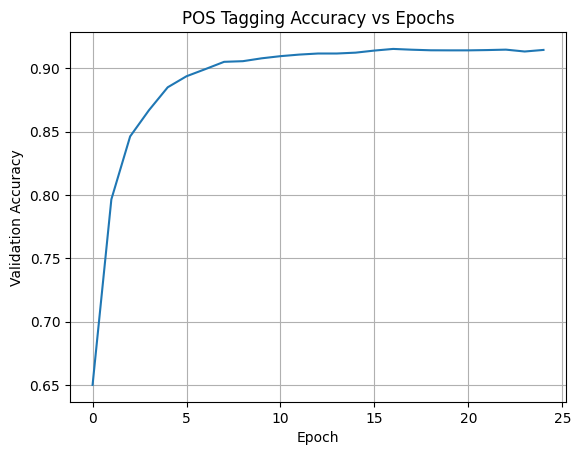

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

plt.plot(accs)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('POS Tagging Accuracy vs Epochs')
plt.grid()
plt.show()
plt.savefig("accuracies.png")

In [ ]:
def is_valid_sentence(tokens):

    for i, token in enumerate(tokens):
        word = token.item()
        if i > 0:  # For all words except the first one
            word_text = [k for k, v in word_to_ix.items() if v == word]
            if word_text and word_text[0][0].isupper():  # Check if the word starts with a capital letter
                return False  # Invalid sentence (non-first word has a capital letter)
    return True

In [ ]:
def visualize_predictions_table(model, data_loader, n_sentences=5, exact_words=12):
    model.eval()
    model = model.to(device)

    samples = []

    with torch.no_grad():
        for x, y in data_loader:
            pred = model(x.to(device))
            pred_classes = pred.argmax(dim=-1).cpu()
            mask = (y != -100)

            for i in range(x.size(0)):
                tokens = x[i]
                true_tags = y[i]
                pred_tags = pred_classes[i]
                valid_len = mask[i].sum().item()

                tokens = tokens[:valid_len]
                true_tags = true_tags[:valid_len]
                pred_tags = pred_tags[:valid_len]

                if len(tokens) == exact_words:  # Only sentences with exactly N words
                    # Check if the sentence makes sense and has no capitalized words (except the first one)
                    sentence = [word for word in tokens]
                    if is_valid_sentence(sentence):  # Apply a filter function
                        samples.append((tokens, true_tags, pred_tags))

            if len(samples) >= n_sentences:
                break

    if len(samples) == 0:
        print(f"❌ No sentences with exactly {exact_words} words found.")
        return

    # Randomly select n_sentences
    random_samples = random.sample(samples, min(n_sentences, len(samples)))

    # Build HTML table
    html = "<table border='1' style='border-collapse: collapse; text-align: center;'>"
    html += "<tr><th>Word</th>" + "".join([f"<th>W{i+1}</th>" for i in range(exact_words)]) + "</tr>"

    for idx, (tokens, true_tags, pred_tags) in enumerate(random_samples):  # Use random samples
        # Word row
        html += f"<tr><td><b>Sentence {idx+1}</b></td>"
        words = []
        for token in tokens:
            word = [k for k, v in word_to_ix.items() if v == token.item()]
            if word:
                words.append(word[0])
            else:
                words.append("?")
        for w in words:
            html += f"<td>{w}</td>"
        html += "</tr>"

        # Tag prediction row
        html += "<tr><td><b>Tags</b></td>"
        for true, pred in zip(true_tags, pred_tags):
            true_tag_idx = true.item()
            pred_tag_idx = pred.item()

            # Decode the indices to tags using the provided tag_names list
            true_tag = ix_to_tag.get(true_tag_idx, "UNK")  # If the index is not found, use "UNK"
            pred_tag = ix_to_tag.get(pred_tag_idx, "UNK")
            name_tag = ix_to_names.get(pred_tag, "UNK")

            # Apply coloring: light green for correct, salmon for incorrect
            color = "forestgreen" if true_tag == pred_tag else "firebrick"
            html += f"<td style='background-color:{color}'>{name_tag}</td>"
        html += "</tr>"

    html += "</table>"

    # Display HTML table
    display(HTML(html))

In [ ]:
visualize_predictions_table(m_gru_bi2, dl_test, n_sentences=5, exact_words=12)

Word,W1,W2,W3,W4,W5,W6,W7,W8,W9,W10,W11,W12
Sentence 1,I,should,think,the,cause,of,progress,got,them,",",anyhow,.
Tags,PRON,AUX,VERB,DET,NOUN,CCONJ,NOUN,VERB,PRON,PART,ADV,PART
Sentence 2,This,type,of,drop,area,is,not,displayed,for,single,charts,.
Tags,DET,NOUN,CCONJ,NOUN,NOUN,AUX,ADP,VERB,CCONJ,ADJ,NOUN,PART
Sentence 3,After,that,",",he,made,a,great,effort,to,be,calm,.
Tags,CCONJ,PRON,PART,PRON,VERB,DET,ADJ,NOUN,ADP,AUX,ADJ,PART
Sentence 4,For,want,of,any,other,idea,",",he,closed,his,eyes,.
Tags,CCONJ,NOUN,CCONJ,DET,ADJ,NOUN,PART,PRON,VERB,PRON,NOUN,PART
Sentence 5,Data,fields,provide,the,values,to,be,summarized,in,the,chart,.
Tags,NOUN,NOUN,VERB,DET,NOUN,ADP,AUX,VERB,CCONJ,DET,NOUN,PART


In [ ]:
important_tags = ["NOUN", "VERB", "ADJ", "ADV", "PRON", "PROPN","DET"]

name_to_ix = {v: k for k, v in ix_to_names.items()}
important_indices = [name_to_ix[tag] for tag in important_tags]

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def compute_confusion_matrix_filtered(model, data_loader):
    model.eval()
    model = model.to(device)

    all_preds = []
    all_trues = []

    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            pred_classes = preds.argmax(dim=-1)

            mask = (y != -100)

            y_flat = y[mask].cpu().numpy()
            pred_flat = pred_classes[mask].cpu().numpy()

            for true_label, pred_label in zip(y_flat, pred_flat):
                if true_label in important_indices:
                    all_trues.append(true_label)
                    all_preds.append(pred_label)

    cm = confusion_matrix(all_trues, all_preds, labels=important_indices)
    return cm

In [ ]:
def plot_confusion_matrix_filtered(cm):
    labels = [ix_to_names[i] for i in important_indices]

    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(xticks_rotation=45, cmap="plasma", ax=ax)
    plt.title("POS Tagging Confusion Matrix")
    plt.grid(False)
    plt.show()

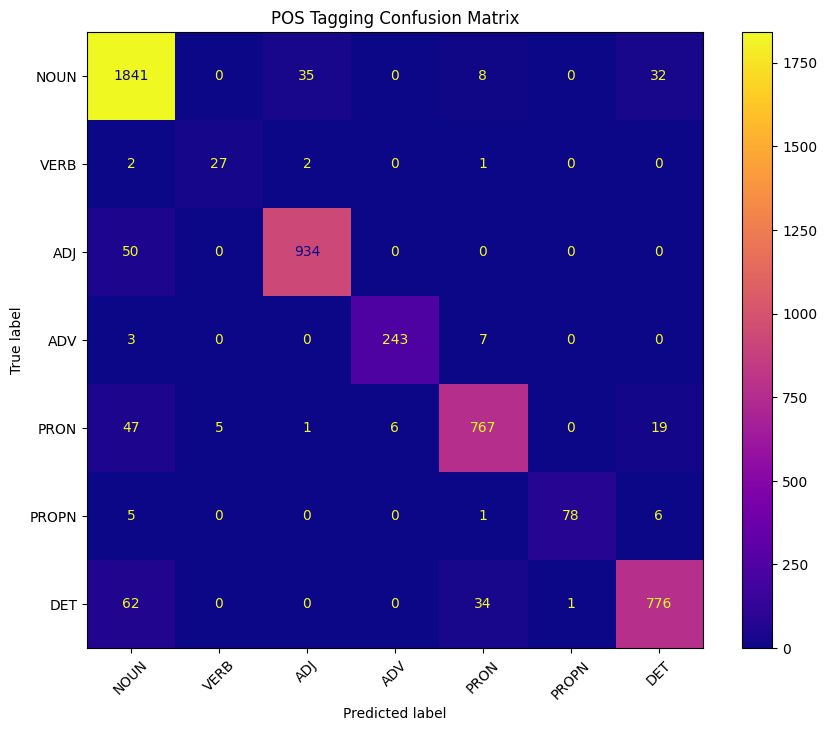

In [ ]:
cm_filtered = compute_confusion_matrix_filtered(m_gru_bi2, dl_test)

plot_confusion_matrix_filtered(cm_filtered)